In [ ]:
# =========================
# 1. IMPORTS
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================
# 2. PATHS
# =========================
train_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/train"
val_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/val"
test_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/test"

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================
# 3. DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =========================
# 4. MODEL
# =========================
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Full fine-tuning
for layer in base_model.layers:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# =========================
# 5. COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# =========================
# 6. CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# =========================
# 7. TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=35,
    callbacks=[early_stop, reduce_lr]
)

# =========================
# 8. SAVE MODEL
# =========================
model.save("/content/drive/MyDrive/densenet_model.keras")

# =========================
# 9. TEST EVALUATION
# =========================
test_loss, test_acc = model.evaluate(test_data)
print("DenseNet Test Accuracy:", test_acc)

Found 3780 images belonging to 3 classes.
Found 1080 images belonging to 3 classes.
Found 540 images belonging to 3 classes.
Epoch 1/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 539s 3s/step - accuracy: 0.5146 - loss: 1.1213 - val_accuracy: 0.5981 - val_loss: 0.9451 - learning_rate: 1.0000e-04
Epoch 2/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 624ms/step - accuracy: 0.5929 - loss: 0.9770 - val_accuracy: 0.6565 - val_loss: 0.8995 - learning_rate: 1.0000e-04
Epoch 3/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 73s 609ms/step - accuracy: 0.6214 - loss: 0.9128 - val_accuracy: 0.6741 - val_loss: 0.8345 - learning_rate: 1.0000e-04
Epoch 4/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 73s 612ms/step - accuracy: 0.6526 - loss: 0.8643 - val_accuracy: 0.7037 - val_loss: 0.8391 - learning_rate: 1.0000e-04
Epoch 5/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 606ms/step - accuracy: 0.6669 - loss: 0.8386 - val_accuracy: 0.6944 - val_loss: 0.8060 - learning_rate: 1.0000e-04
Epoch 6/35
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 602ms/step - accuracy: 0.6918 - loss: 

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/densenet_model.keras")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Knee Osteoarthritis Classification/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 540 images belonging to 3 classes.


In [ ]:
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

17/17 ━━━━━━━━━━━━━━━━━━━━ 293s 17s/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

      Normal       0.93      0.83      0.88       180
  Osteopenia       0.87      0.97      0.92       180
Osteoporosis       0.83      0.83      0.83       180

    accuracy                           0.88       540
   macro avg       0.88      0.88      0.88       540
weighted avg       0.88      0.88      0.88       540



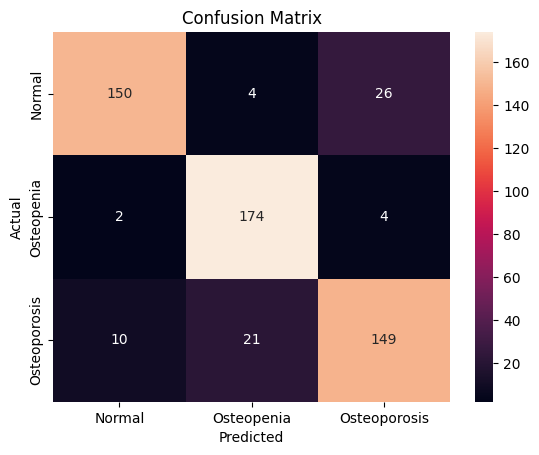

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

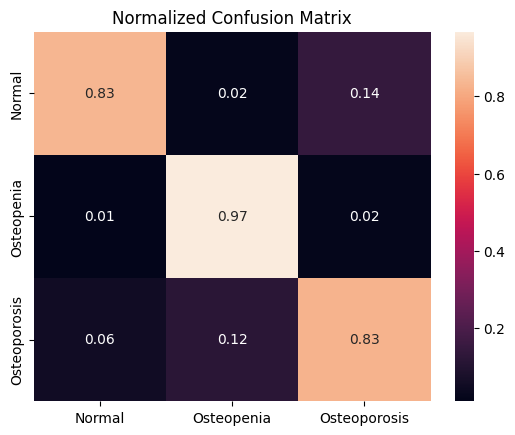

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Normalized Confusion Matrix')
plt.show()

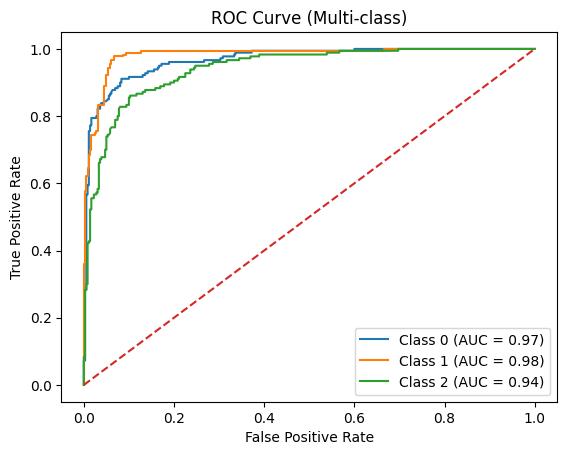

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to binary (for multi-class)
y_true_bin = label_binarize(y_true, classes=[0,1,2])

n_classes = y_true_bin.shape[1]

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/densenet_model.keras")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Knee Osteoarthritis Classification/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 540 images belonging to 3 classes.


In [ ]:
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

17/17 ━━━━━━━━━━━━━━━━━━━━ 285s 17s/step


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_classes
)

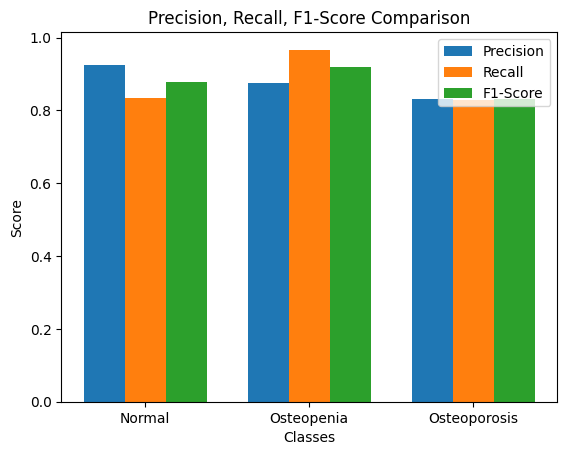

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(class_names))
width = 0.25

plt.figure()

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')

plt.xticks(x, class_names)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Precision, Recall, F1-Score Comparison")
plt.legend()

plt.show()

In [ ]:
for i, class_name in enumerate(class_names):
    print(f"{class_name}:")
    print(f" Precision: {precision[i]:.3f}")
    print(f" Recall: {recall[i]:.3f}")
    print(f" F1-score: {f1[i]:.3f}")
    print()

Normal:
 Precision: 0.926
 Recall: 0.833
 F1-score: 0.877

Osteopenia:
 Precision: 0.874
 Recall: 0.967
 F1-score: 0.918

Osteoporosis:
 Precision: 0.832
 Recall: 0.828
 F1-score: 0.830

